<a href="https://colab.research.google.com/github/Psyche-1/goit-ds-hw/blob/main/Hw7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y scikit-surprise numpy
!pip install "numpy<2.0.0" scikit-surprise
import os
os.kill(os.getpid(), 9)

In [2]:
from surprise import Dataset, Reader, SVD, SVDpp, NMF
from surprise.model_selection import GridSearchCV, cross_validate

In [7]:
import numpy as np
from scipy.io import loadmat

In [21]:
import matplotlib.pyplot as plt

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
file_path_movies = '/content/drive/MyDrive/Colab Notebooks/Data/data_7/movies.mat'

In [13]:
file_path_movie_ids = '/content/drive/MyDrive/Colab Notebooks/Data/data_7/movie_ids.txt'

In [3]:
data = Dataset.load_builtin('ml-100k')

Dataset ml-100k could not be found. Do you want to download it? [Y/n] Y
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k


In [4]:
param_grid = {
    'n_epochs': [10, 20],
    'lr_all': [0.002, 0.005],
    'reg_all': [0.4, 0.6]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data)

print(f"Best RMSE for SVD: {gs.best_score['rmse']}")
print(f"Best params: {gs.best_params['rmse']}")

Best RMSE for SVD: 0.9592122386062152
Best params: {'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.4}


In [6]:
algorithms = {
    'SVD': SVD(
        n_epochs=gs.best_params['rmse']['n_epochs'],
        lr_all=gs.best_params['rmse']['lr_all'],
        reg_all=gs.best_params['rmse']['reg_all']
    ),
    'SVD++': SVDpp(),
    'NMF': NMF()
}

for name, algo in algorithms.items():
    results = cross_validate(algo, data, measures=['RMSE'], cv=3, verbose=False)
    mean_rmse = results['test_rmse'].mean()
    print(f"{name}: mean RMSE = {mean_rmse:.4f}")

SVD: mean RMSE = 0.9594
SVD++: mean RMSE = 0.9294
NMF: mean RMSE = 0.9751


In [20]:
data = loadmat(file_path_movies)
Y, R = data['Y'], data['R']

In [16]:
Y, R

(array([[5, 4, 0, ..., 5, 0, 0],
        [3, 0, 0, ..., 0, 0, 5],
        [4, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 array([[1, 1, 0, ..., 1, 0, 0],
        [1, 0, 0, ..., 0, 0, 1],
        [1, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

Average rating for movie 1601 ( Office Killer (1997) ): 0.000000 / 5


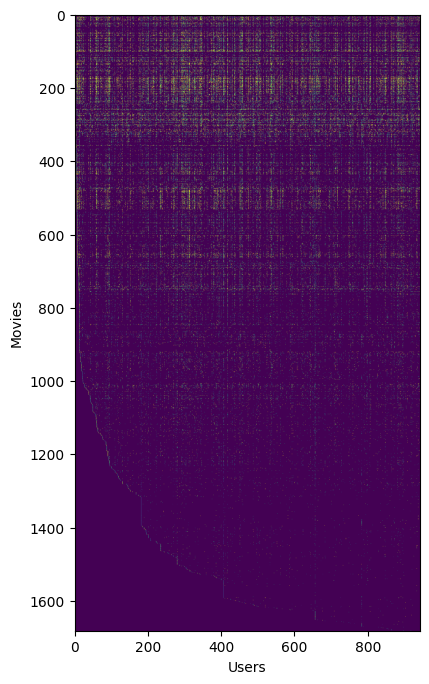

In [22]:
print('Average rating for movie 1601 (',names[1600] ,'): %f / 5' %
      np.mean(Y[1600, R[0, :]]))

plt.figure(figsize=(8, 8))
plt.imshow(Y)
plt.ylabel('Movies')
plt.xlabel('Users')
plt.grid(False)

In [14]:
def loadMovieList():
    """
    Reads the fixed movie list in movie_ids.txt and returns a list of movie names.
    Returns
    -------
    movieNames : list
        A list of strings, representing all movie names.
    """
    # Read the fixed movieulary list
    with open(file_path_movie_ids,  encoding='ISO-8859-1') as fid:
        movies = fid.readlines()

    movieNames = []
    for movie in movies:
        parts = movie.split()
        movieNames.append(' '.join(parts[1:]).strip())
    return movieNames

In [30]:
movies = loadMovieList()

In [24]:
def cofi_loss(X, W, Y, R, lmbda):
  predictions = (X @ W.T)

  error = (predictions - Y) * R

  loss = (1/2) * np.sum(np.square(error))

  reg = (lmbda/2) * (np.sum(np.square(W)) + np.sum(np.square(X)))

  return loss + reg

In [25]:
def cofi_gradient_step(X, W, Y, R, alpha, lmbda):
    error = (X @ W.T - Y) * R

    X_grad = (error @ W) + lmbda * X
    W_grad = (error.T @ X) + lmbda * W

    X = X - alpha * X_grad
    W = W - alpha * W_grad

    return X, W

In [28]:
def train_matrix_factorization(Y, R, num_features=10, alpha=0.001, lmbda=1.0, iterations=100):
    num_movies, num_users = Y.shape

    X = np.random.randn(num_movies, num_features)
    W = np.random.randn(num_users, num_features)

    loss_history = []
    for i in range(iterations):
        X, W = cofi_gradient_step(X, W, Y, R, alpha, lmbda)
        loss = cofi_loss(X, W, Y, R, lmbda)
        loss_history.append(loss)
        if i % 100 == 0:
            print(f"Iteration {i}: loss = {loss:.2f}")

    return X, W, loss_history

In [29]:
Y_mean = np.zeros((Y.shape[0], 1))
Y_norm = np.zeros(Y.shape)
for i in range(Y.shape[0]):
    idx = np.where(R[i, :] == 1)
    Y_mean[i] = np.mean(Y[i, idx])
    Y_norm[i, idx] = Y[i, idx] - Y_mean[i]

X_final, W_final, history = train_matrix_factorization(Y_norm, R, iterations=1000)

all_predictions = X_final @ W_final.T + Y_mean

Iteration 0: loss = 276070.22
Iteration 100: loss = 47345.20
Iteration 200: loss = 40484.42
Iteration 300: loss = 36542.76
Iteration 400: loss = 33979.31
Iteration 500: loss = 32228.50
Iteration 600: loss = 30973.84
Iteration 700: loss = 30056.90
Iteration 800: loss = 29381.38
Iteration 900: loss = 28878.88


In [31]:
user_preds = all_predictions[:, 0]
top_idx = np.argsort(user_preds)[::-1][:10]

for i in top_idx:
    print(f"Prediction {user_preds[i]:.1f}: {movies[i]}")

Prediction 5.4: Citizen Kane (1941)
Prediction 5.4: Wrong Trousers, The (1993)
Prediction 5.3: Leaving Las Vegas (1995)
Prediction 5.2: Top Hat (1935)
Prediction 5.2: World of Apu, The (Apur Sansar) (1959)
Prediction 5.2: Saint of Fort Washington, The (1993)
Prediction 5.2: Living in Oblivion (1995)
Prediction 5.1: Letter From Death Row, A (1998)
Prediction 5.1: Laura (1944)
Prediction 5.1: Paths of Glory (1957)
